In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


In [1]:
import os
import multiprocessing as mp

cpu_cap = 30
cpu_count = mp.cpu_count()
cpu_use = min(cpu_cap, cpu_count)
os.environ["MY_CPU_COUNT"] = str(cpu_use)
os.environ["OMP_NUM_THREADS"] = str(cpu_use)
os.environ["OPENBLAS_NUM_THREADS"] = str(cpu_use)
os.environ["MKL_NUM_THREADS"] = str(cpu_use)
os.environ["NUMEXPR_MAX_THREADS"] = str(cpu_use)
try:
    os.sched_setaffinity(0, set(range(cpu_use)))
except Exception as exc:
    print(f"CPU affinity not set: {exc}")
print(os.sched_getaffinity(0))

import numpy as np
import matplotlib.pyplot as plt
import importlib
import fgtn.classA_U1FGTN as mod  # import the module
importlib.reload(mod)        # reload the module
from fgtn.classA_U1FGTN import classA_U1FGTN  # pull the class after reload


{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29}


In [2]:
# Cell 2: instantiate the model (DW off, topological mass = 1)
Nx = 12
Ny = 30
model = classA_U1FGTN(
    Nx=Nx,
    Ny=Ny,
    DW=True,        
    nshell=2,
    alpha_1=30,      # mass has non-trans-invariant profile if alpha_1 != alpha_2
    alpha_2=1,      # only alpha_1 matters when DW=False 
)


DWs at x=(4, 8)
------------------------- classA_U1FGTN Initialized -------------------------


In [3]:
# Cell 3: run deterministic Markov channel (no history, no saving)
result = model.run_markov_channel(
    G_history=True,
    progress=True,
    cycles=120,   # choose your total cycles; adjust as needed
    p=1,
    init_mode="default",
    save=True,
    n_a=0.5,
    sequence='dw_symmetric_y',
    top_triv_back_forth=True,
    top_triv_block_cycles=15
)

G_ss = result["G_final"]  # steady-state top-layer covariance
G_ss.shape


Markov channel (sites):   0%|          | 0/21600 [00:00<?, ?site/s]

[info] Markov channel will save history to cache/G_history_samples/N12x30_S120_nsh2_DW1_init-default_n_a0.5_p1_exclNone_tbtf1_tbtfbc15_markov_channel.npz


(720, 720)

In [8]:

res = model.check_y_translation_invariance(G_ss)
print(res)

def symmetrize_y_translation(G, Nx, Ny):
    """
    Symmetrizes a 2-point function G_ij with respect to y-translation.
    
    The composite index is assumed to be: j = mu + 2*x + 2*Nx*y
    (Ordered: y slowest, x middle, mu fastest)
    
    Parameters
    ----------
    G : (N_tot, N_tot) ndarray
        The input covariance or Green's function matrix.
        N_tot must equal 2 * Nx * Ny.
    Nx, Ny : int
        Lattice dimensions.
        
    Returns
    -------
    G_sym : (N_tot, N_tot) ndarray
        The y-translation invariant matrix. 
        G_sym(y, y') will depend only on (y - y') mod Ny.
    """
    N_tot = 2 * Nx * Ny
    if G.shape != (N_tot, N_tot):
        raise ValueError(f"Matrix shape {G.shape} does not match 2*Nx*Ny = {N_tot}")
    
    # 1. Reshape G to separate the indices (y, x_comp)
    # The stride for y is 2*Nx. The 'inner' dimension has size 2*Nx (covering x and mu).
    # New shape: (Ny, 2*Nx, Ny, 2*Nx)
    # Indices are: [y_row, x_row_composite, y_col, x_col_composite]
    G_reshaped = G.reshape(Ny, 2*Nx, Ny, 2*Nx)
    
    # 2. Perform Group Averaging
    # G_sym = (1/Ny) * sum_{s} G(y+s, y'+s)
    # In array terms, G(y+s) corresponds to rolling the array 'backwards' by s.
    
    G_sum = np.zeros_like(G_reshaped)
    
    print("Symmetrizing over y-translations...")
    for s in range(Ny):
        # Roll axis 0 (y_row) and axis 2 (y_col) by -s
        # np.roll with shift=-s moves index s to index 0 (y -> y+s)
        G_shifted = np.roll(G_reshaped, shift=(-s, -s), axis=(0, 2))
        G_sum += G_shifted
        
    G_sym_reshaped = G_sum / Ny
    
    # 3. Flatten back to original shape
    G_sym = G_sym_reshaped.reshape(N_tot, N_tot)
    
    return G_sym

G_ss_2 = symmetrize_y_translation(G_ss, Nx, Ny)
res = model.check_y_translation_invariance(G_ss_2)
print(res)

{'shape_ok': True, 'Ny': 30, 'shift_max_abs_diff': 0.008416240554459322, 'shift_pass': False, 'offdiag_ratio': 6.204417682519331e-05, 'offdiag_pass': False}
Symmetrizing over y-translations...
{'shape_ok': True, 'Ny': 30, 'shift_max_abs_diff': 2.220446049250313e-16, 'shift_pass': True, 'offdiag_ratio': 6.608573406983385e-32, 'offdiag_pass': True}


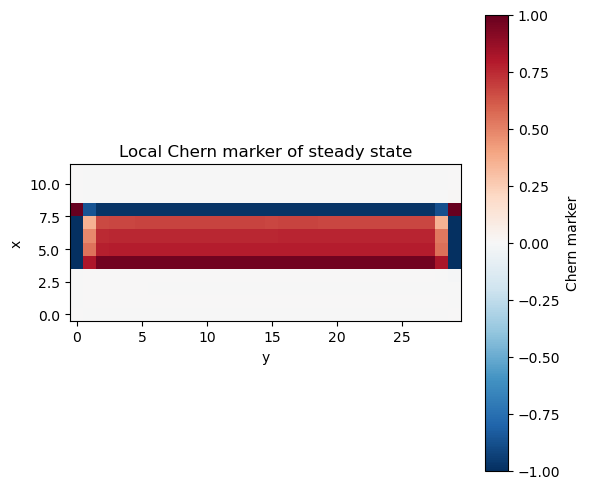

In [4]:
# Cell 5: plot the local Chern marker
C = model.local_chern_marker_flat(G_ss)
plt.figure(figsize=(6, 5))
im = plt.imshow(C, origin="lower", cmap="RdBu_r")
plt.colorbar(im, label="Chern marker")
plt.title("Local Chern marker of steady state")
plt.xlabel("y")
plt.ylabel("x")
plt.tight_layout()
plt.show()


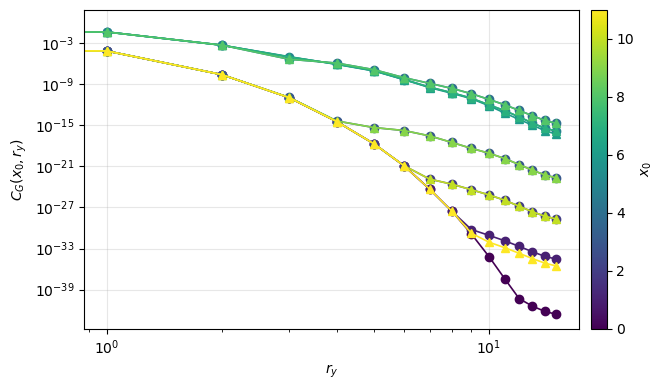

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from fgtn.classA_U1FGTN import classA_U1FGTN
G_top = G_ss
Nlayer = 2*Nx*Ny

# --- Correlation helper (matches plot_corr_y_profiles) ---
G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
Gker = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (x,y,2,x',y',2)

ry_max = Ny // 2
ry_vals = np.arange(0, ry_max + 1, dtype=int)

# --- Plot y-profiles for all x with colorbar ---
fig, ax = plt.subplots(figsize=(7, 4))

cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=Nx - 1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
marker = ['o', '^']
for x0 in range(Nx):
    Gx = Gker[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny, dtype=np.intp)[:, None]
    Yp = (Y + ry_vals[None, :]) % Ny
    Gx_re = np.transpose(Gx, (0, 2, 1, 3)).reshape(Ny * Ny, 2, 2)
    flat_ix = (Y * Ny + Yp).reshape(-1)
    blocks = Gx_re[flat_ix].reshape(Ny, ry_vals.size, 2, 2)
    C_vec = np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny)
    if x0 < Nx//2:
        ax.plot(ry_vals, C_vec.real, marker=marker[0], lw=1.2, color=cmap(norm(x0)))
    else:
        ax.plot(ry_vals, C_vec.real, marker=marker[1], lw=1.2, color=cmap(norm(x0)))
        
ax.set_xlabel(r"$r_y$")
ax.set_ylabel(r"$C_G(x_0, r_y)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$x_0$")

plt.tight_layout()
plt.show()


In [7]:
# --- Entanglement cut at y = Ny//2; keep upper half (use yA = np.arange(0, y_cut) for lower half) ---

s_map = model.entanglement_contour(G_ss)  # shape: (Nx, Ny_sub)

# Plot: heatmap + y-cuts at fixed x with gradient colors
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.2]})

# Heatmap
im2 = axes[0].imshow(s_map, origin="lower", cmap="magma", aspect="auto")
fig.colorbar(im2, ax=axes[0], label="Entanglement contour s(r)")
axes[0].set_title("Entanglement contour (subsystem y >= Ny//2)")
axes[0].set_xlabel("y (subsystem)")
axes[0].set_ylabel("x")

# y-cuts at fixed x
y_vals = np.arange(Ny)
x_list = np.arange(Nx)  # change to a subset if you want fewer lines
colors = plt.cm.viridis(np.linspace(0, 1, len(x_list)))
markers = ['o','^']
for x_idx, color in zip(x_list, colors):
    if x_idx < Nx//2:
        axes[1].plot(y_vals, s_map[x_idx, :], marker=markers[0], color=color, lw=1.8, label=f"x = {x_idx}")
    else:
        axes[1].plot(y_vals, s_map[x_idx, :], marker=markers[1], color=color, lw=1.8, label=f"x = {x_idx}")
axes[1].set_xlabel("y")
axes[1].set_ylabel("s(x, y)")
axes[1].set_title("Cuts vs y for fixed x")
axes[1].grid(alpha=0.3, linestyle="--", linewidth=0.8)
axes[1].set_yscale('linear')

# Colorbar for x values
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=x_list.min(), vmax=x_list.max()))
sm.set_array([])
fig.colorbar(sm, ax=axes[1], label="x")

plt.tight_layout()
plt.show()


TypeError: classA_U1FGTN.entanglement_contour() missing 2 required positional arguments: 'Nx' and 'Ny'

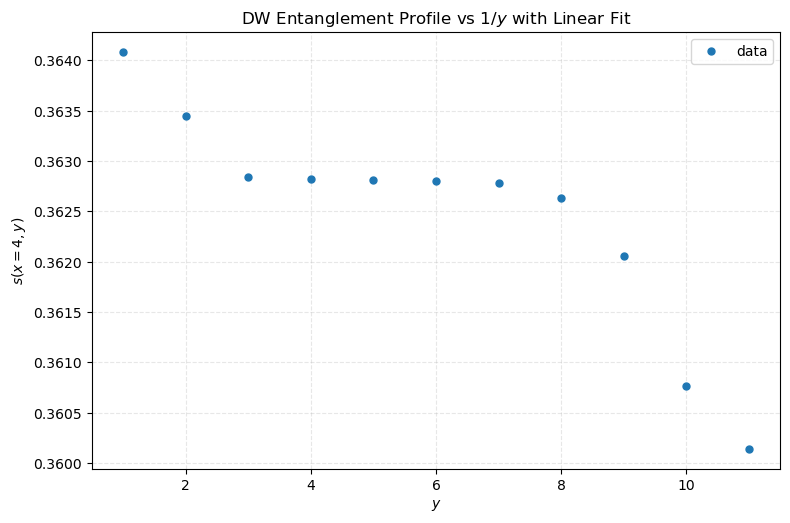

In [12]:
import numpy as np
import matplotlib.pyplot as plt

y_vals = np.arange(1, Ny)
s_curve_dw = s_map[4, int(y_vals[0]):int(y_vals[-1] + 1)]

x = y_vals
y = s_curve_dw

# Fit y = m x + b
#m, b = np.polyfit(x, y, 1)
#print(f"slope = {m:.6g}, intercept = {b:.6g}")
#
## R^2 and adjusted R^2
#y_hat = m * x + b
#ss_res = np.sum((y - y_hat) ** 2)
#ss_tot = np.sum((y - np.mean(y)) ** 2)
#r2 = 1 - ss_res / ss_tot
#n = len(y)
#p = 1  # one predictor
#adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
#print(f"R^2 = {r2:.6g}, adjusted R^2 = {adj_r2:.6g}")

fig, ax = plt.subplots(figsize=(8, 16/3))
ax.plot(x, y, "o", ms=5, label="data")
#ax.plot(x, m*x + b, "-", lw=2, label=f"fit: slope={m:.4g}")
ax.set_xlabel(r"$y$")
ax.set_ylabel(r"$s(x{=}4,y)$")
ax.set_title(r"DW Entanglement Profile vs $1/y$ with Linear Fit")
ax.grid(alpha=0.3, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()


In [1]:
# Compute and plot gauge-invariant current maps from steady state G_ss
J_x, J_y = model.current_maps_gauge_invariant(G_ss)
fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), sharey=True, vmin=-0.005, vmax=0.005)
plt.show()
#print(model.DW_loc)

NameError: name 'model' is not defined

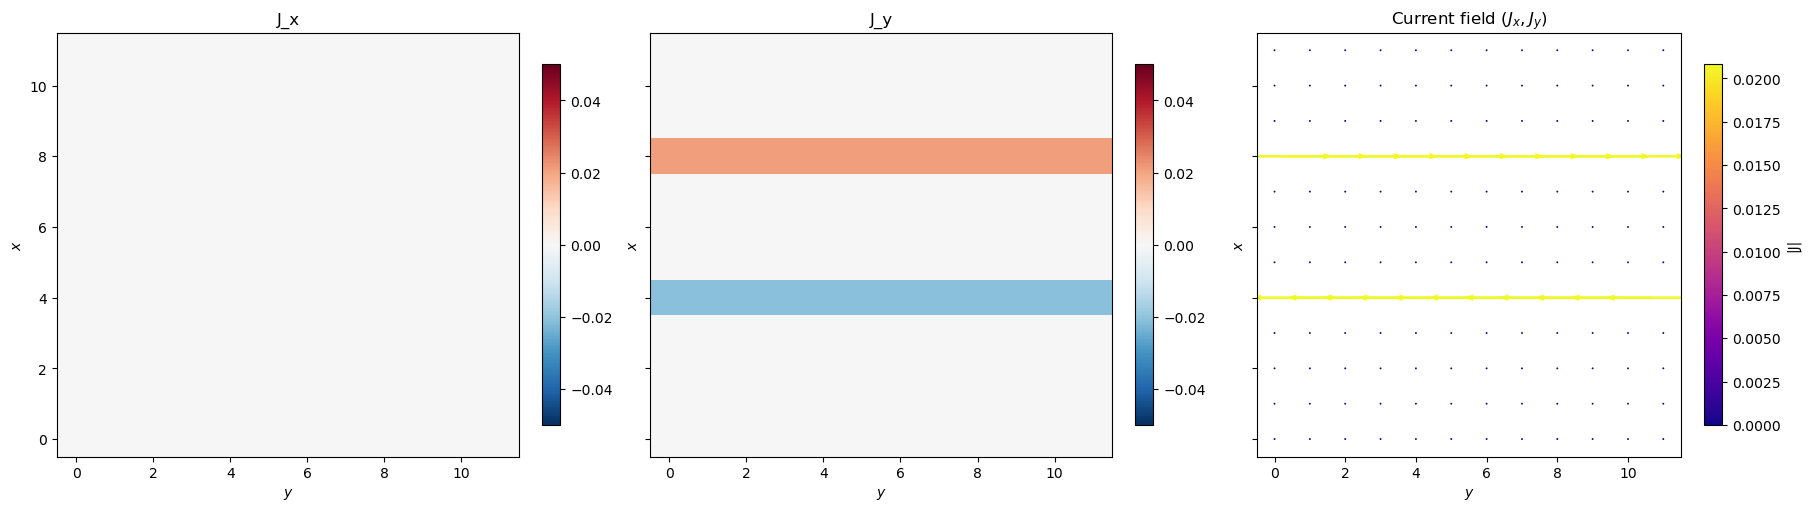

In [55]:
G_CI_DW = model.G_CI_domain_wall()
J_x, J_y = model.current_maps_gauge_invariant(G_CI_DW)
fig, axes = model.plot_current_maps(J_x, J_y, figsize=(18, 5), sharey=True, vmin=-0.05, vmax=+0.05)
plt.show()

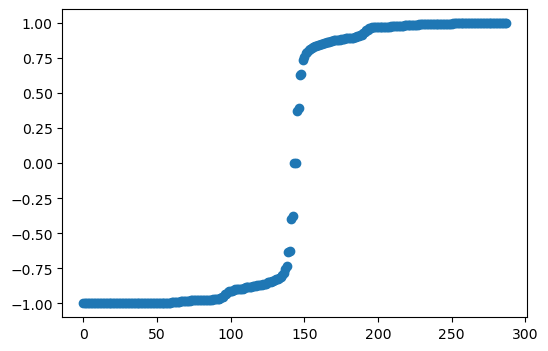

In [103]:
eigvals = np.linalg.eigvalsh(G_ss)
plt.figure(figsize=(6, 4))
plt.plot(eigvals, "o")

In [104]:
# Check y-translation invariance of the steady-state top-layer covariance G_ss
report = model.check_y_translation_invariance(G_ss, tol_shift=1e-10, tol_offdiag=1e-10, hermitize=True)
print(report)


{'shape_ok': True, 'Ny': 12, 'shift_max_abs_diff': 0.3315696436347618, 'shift_pass': False, 'offdiag_ratio': 0.022411073700519892, 'offdiag_pass': False}


DWs at x=(4, 11)
------------------------- classA_U1FGTN Initialized -------------------------


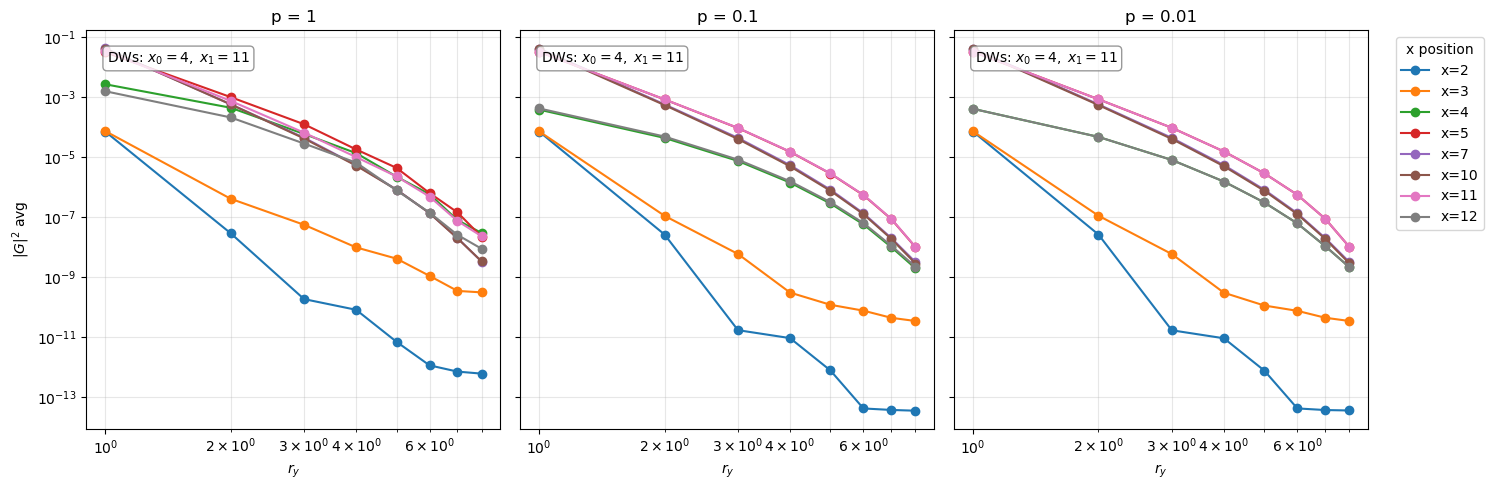

In [57]:
# random sequence version

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fgtn.classA_U1FGTN import classA_U1FGTN
# Match the generation run
P_LIST = [1.0, 1e-1, 1e-2]
CYCLES = 20
Nx = Ny = 16

# Instantiate to reuse DW locations/shapes
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, nshell=None, alpha_1=30, alpha_2=1)
xL, xR = model.DW_loc

def _pick_x_positions():
    xs = [
        (xL // 2) % Nx,
        (xL - 1) % Nx, xL % Nx, (xL + 1) % Nx,
        ((xL + xR) // 2) % Nx,
        (xR - 1) % Nx, xR % Nx, (xR + 1) % Nx,
        (xR + (Nx // 2)) % Nx,
    ]
    seen, uniq = set(), []
    for x in xs:
        if x not in seen:
            uniq.append(int(x)); seen.add(int(x))
    return [(x, f"{x}") for x in uniq]

def expected_path(p):
    sweeps = int(round(CYCLES / p))
    key = f"N{Nx}x{Ny}_S{sweeps}_nshNone_DW1_init-default_n_a0.5_p{p}_markov_channel_DW1_seq_ran.npz"
    return Path("cache") / "G_history_samples" / key

def corr_y_profile(G_top, x0):
    """Return (ry_vals, profile) for ry=1..Ny//2."""
    Nlayer = 2 * Nx * Ny
    G_top = np.asarray(G_top, dtype=np.complex128)
    if G_top.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected ({Nlayer},{Nlayer}), got {G_top.shape}")

    G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
    G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    G6 = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2, Nx,Ny,2)

    ry_vals = np.arange(1, Ny // 2 + 1, dtype=int)  # start at 1
    Ny_loc = Ny
    x0 = int(x0) % Nx

    Gx = G6[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny_loc, dtype=np.intp)[:, None]
    prof = []
    for ry in ry_vals:
        Yp = (Y + ry) % Ny_loc
        blocks = Gx[Y, :, Yp, :]  # (Ny,2,2)
        prof.append(np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny_loc))
    return ry_vals, np.array(prof, dtype=float)

# Load and collect profiles
profiles = {}  # p -> list of (label, ry, values)
xs = _pick_x_positions()
for p in P_LIST:
    path = expected_path(p)
    if not path.exists():
        print(f"Skipping p={p}: missing {path}")
        continue
    data = np.load(path)
    G_ss = data["G_final"]
    entries = []
    for x, label in xs:
        ry, vals = corr_y_profile(G_ss, x)
        entries.append((label, ry, vals))
    profiles[p] = entries

# Plot: one subplot per p, log-log
fig, axes = plt.subplots(1, len(profiles), figsize=(5 * max(1, len(profiles)), 5), sharey=True)
if len(profiles) == 1:
    axes = [axes]

for ax, p in zip(axes, profiles):
    for label, ry, vals in profiles[p]:
        ax.plot(ry, vals, marker="o", label=f"x={label}")
        ax.set_yscale("log")
        ax.set_xscale("log")
    ax.set_title(f"p = {p:g}")
    ax.set_xlabel(r"$r_y$")
    ax.grid(True, which="both", alpha=0.3)
    # Add DW textbox
    ax.text(
        0.05, 0.95,
        f"DWs: $x_0={xL},\\;x_1={xR}$",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.3")
    )

axes[0].set_ylabel(r"$|G|^2$ avg")
axes[-1].legend(title="x position", bbox_to_anchor=(1.05, 1.0), loc="upper left")


plt.tight_layout()
plt.show()


DWs at x=(4, 11)
------------------------- classA_U1FGTN Initialized -------------------------
Skipping p=0.01: missing cache/G_history_samples/N16x16_S2000_nshNone_DW1_init-default_n_a0.5_p0.01_markov_channel_DW1_seq_def.npz


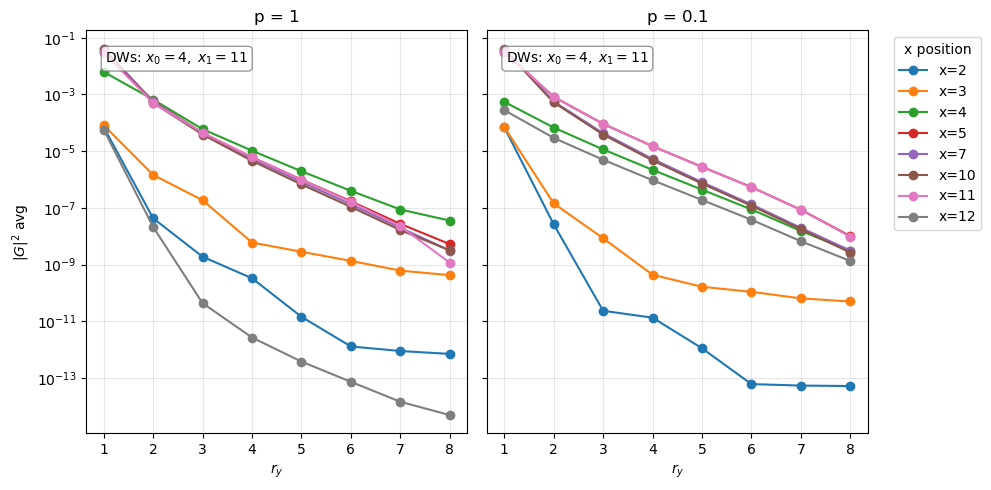

In [1]:
# default sequence version

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fgtn.classA_U1FGTN import classA_U1FGTN
# Match the generation run
P_LIST = [1.0, 1e-1, 1e-2]
CYCLES = 20
Nx = Ny = 16

# Instantiate to reuse DW locations/shapes
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, nshell=None, alpha_1=30, alpha_2=1)
xL, xR = model.DW_loc

def _pick_x_positions():
    xs = [
        (xL // 2) % Nx,
        (xL - 1) % Nx, xL % Nx, (xL + 1) % Nx,
        ((xL + xR) // 2) % Nx,
        (xR - 1) % Nx, xR % Nx, (xR + 1) % Nx,
        (xR + (Nx // 2)) % Nx,
    ]
    seen, uniq = set(), []
    for x in xs:
        if x not in seen:
            uniq.append(int(x)); seen.add(int(x))
    return [(x, f"{x}") for x in uniq]

def expected_path(p):
    sweeps = int(round(CYCLES / p))
    key = f"N{Nx}x{Ny}_S{sweeps}_nshNone_DW1_init-default_n_a0.5_p{p}_markov_channel_DW1_seq_def.npz"
    return Path("cache") / "G_history_samples" / key

def corr_y_profile(G_top, x0):
    """Return (ry_vals, profile) for ry=1..Ny//2."""
    Nlayer = 2 * Nx * Ny
    G_top = np.asarray(G_top, dtype=np.complex128)
    if G_top.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected ({Nlayer},{Nlayer}), got {G_top.shape}")

    G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
    G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    G6 = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2, Nx,Ny,2)

    ry_vals = np.arange(1, Ny // 2 + 1, dtype=int)  # start at 1
    Ny_loc = Ny
    x0 = int(x0) % Nx

    Gx = G6[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny_loc, dtype=np.intp)[:, None]
    prof = []
    for ry in ry_vals:
        Yp = (Y + ry) % Ny_loc
        blocks = Gx[Y, :, Yp, :]  # (Ny,2,2)
        prof.append(np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny_loc))
    return ry_vals, np.array(prof, dtype=float)

# Load and collect profiles
profiles = {}  # p -> list of (label, ry, values)
xs = _pick_x_positions()
for p in P_LIST:
    path = expected_path(p)
    if not path.exists():
        print(f"Skipping p={p}: missing {path}")
        continue
    data = np.load(path)
    G_ss = data["G_final"]
    entries = []
    for x, label in xs:
        ry, vals = corr_y_profile(G_ss, x)
        entries.append((label, ry, vals))
    profiles[p] = entries

# Plot: one subplot per p, log-log
fig, axes = plt.subplots(1, len(profiles), figsize=(5 * max(1, len(profiles)), 5), sharey=True)
if len(profiles) == 1:
    axes = [axes]

for ax, p in zip(axes, profiles):
    for label, ry, vals in profiles[p]:
        ax.plot(ry, vals, marker="o", label=f"x={label}")
        ax.set_yscale("log")
        ax.set_xscale("linear")
    ax.set_title(f"p = {p:g}")
    ax.set_xlabel(r"$r_y$")
    ax.grid(True, which="both", alpha=0.3)
    # Add DW textbox
    ax.text(
        0.05, 0.95,
        f"DWs: $x_0={xL},\\;x_1={xR}$",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.3")
    )

axes[0].set_ylabel(r"$|G|^2$ avg")
axes[-1].legend(title="x position", bbox_to_anchor=(1.05, 1.0), loc="upper left")


plt.tight_layout()
plt.show()


DWs at x=(5, 14)
------------------------- classA_U1FGTN Initialized -------------------------


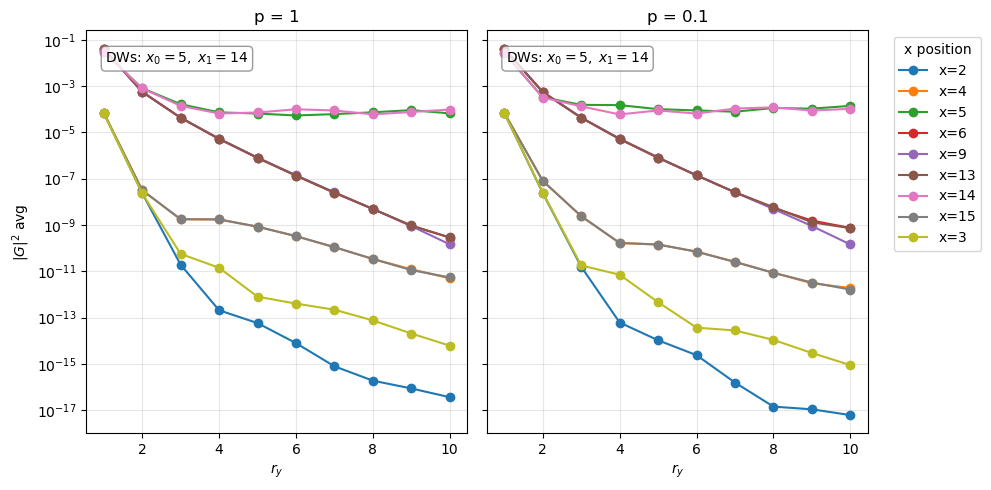

In [2]:
# default sequence version

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fgtn.classA_U1FGTN import classA_U1FGTN
# Match the generation run
P_LIST = [1.0, 1e-1]
CYCLES = 20
Nx = Ny = 21

# Instantiate to reuse DW locations/shapes
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True, nshell=None, alpha_1=30, alpha_2=1)
xL, xR = model.DW_loc

def _pick_x_positions():
    xs = [
        (xL // 2) % Nx,
        (xL - 1) % Nx, xL % Nx, (xL + 1) % Nx,
        ((xL + xR) // 2) % Nx,
        (xR - 1) % Nx, xR % Nx, (xR + 1) % Nx,
        (xR + (Nx // 2)) % Nx,
    ]
    seen, uniq = set(), []
    for x in xs:
        if x not in seen:
            uniq.append(int(x)); seen.add(int(x))
    return [(x, f"{x}") for x in uniq]

def expected_path(p):
    sweeps = int(round(CYCLES / p))
    key = f"N{Nx}x{Ny}_S{sweeps}_nshNone_DW1_init-default_n_a0.5_p{p}_markov_channel_DW1_seq_symm_dw_exclude.npz"
    return Path("cache") / "G_history_samples" / key

def corr_y_profile(G_top, x0):
    """Return (ry_vals, profile) for ry=1..Ny//2."""
    Nlayer = 2 * Nx * Ny
    G_top = np.asarray(G_top, dtype=np.complex128)
    if G_top.shape != (Nlayer, Nlayer):
        raise ValueError(f"Expected ({Nlayer},{Nlayer}), got {G_top.shape}")

    G2 = 0.5 * (G_top + np.eye(Nlayer, dtype=np.complex128))
    G6 = G2.reshape(2, Nx, Ny, 2, Nx, Ny, order="F")
    G6 = np.transpose(G6, (1, 2, 0, 4, 5, 3))  # (Nx,Ny,2, Nx,Ny,2)

    ry_vals = np.arange(1, Ny // 2 + 1, dtype=int)  # start at 1
    Ny_loc = Ny
    x0 = int(x0) % Nx

    Gx = G6[x0, :, :, x0, :, :]  # (Ny,2,Ny,2)
    Y = np.arange(Ny_loc, dtype=np.intp)[:, None]
    prof = []
    for ry in ry_vals:
        Yp = (Y + ry) % Ny_loc
        blocks = Gx[Y, :, Yp, :]  # (Ny,2,2)
        prof.append(np.sum(np.abs(blocks) ** 2, axis=(0, 2, 3)) / (2.0 * Ny_loc))
    return ry_vals, np.array(prof, dtype=float)

# Load and collect profiles
profiles = {}  # p -> list of (label, ry, values)
xs = _pick_x_positions()
for p in P_LIST:
    path = expected_path(p)
    if not path.exists():
        print(f"Skipping p={p}: missing {path}")
        continue
    data = np.load(path)
    G_ss = data["G_final"]
    entries = []
    for x, label in xs:
        ry, vals = corr_y_profile(G_ss, x)
        entries.append((label, ry, vals))
    profiles[p] = entries

# Plot: one subplot per p, log-log
fig, axes = plt.subplots(1, len(profiles), figsize=(5 * max(1, len(profiles)), 5), sharey=True)
if len(profiles) == 1:
    axes = [axes]

for ax, p in zip(axes, profiles):
    for label, ry, vals in profiles[p]:
        ax.plot(ry, vals, marker="o", label=f"x={label}")
        ax.set_yscale("log")
        ax.set_xscale("linear")
    ax.set_title(f"p = {p:g}")
    ax.set_xlabel(r"$r_y$")
    ax.grid(True, which="both", alpha=0.3)
    # Add DW textbox
    ax.text(
        0.05, 0.95,
        f"DWs: $x_0={xL},\\;x_1={xR}$",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.3")
    )

axes[0].set_ylabel(r"$|G|^2$ avg")
axes[-1].legend(title="x position", bbox_to_anchor=(1.05, 1.0), loc="upper left")


plt.tight_layout()
plt.show()
